# Descente de gradient

On a vu la régression linéaire à plusieurs variables et l'algo du SVM sans réellement les coder. On se penche là-dessus dans ce module.

Ce module va nous permettre de comprendre les principes derrière l'entraînement des **réseaux de neurones** (prochain module).

In [ ]:
#@title Importations
import numpy as np
import pandas as pd
import plotly.express as px

## Optimisation mathématique

À l'exception de KNN (qui n'est pas très bon) tous les algorithmes qu'on a regardés étaient formulés comme des problèmes **d'optimisation mathématique**.

&nbsp;

**Régression linéaire**

$$\text{minimiser } \sum_{i}^N (y_i - y_{\text{prediction } i})^2$$

**Régression Ridge** (régression linéaire avec régularisation L2)

$$\text{minimiser } \sum_{i}^N (y_i - y_{\text{prediction } i})^2 + \alpha \sum_{i=0}^N m_i^2$$

**SVM**

\begin{align}
\text{minimiser }~ &\frac{1}{\text{distance entre les deux droites}} + C ( ~ \frac{1}{N} \sum_i^N \text{hinge}(x_i) ~)
\end{align}

&nbsp;

Ce qui soulève la question : **comment on code une minimisation?**

## Méthode stupide : tout tester

La **recherche sur une grille** (*grid search*) est une option qu'on peut considérer :

```python
for x in valeurs_possibles:
  print(x, f(x))
```

Par exemple, on pourrait tester tous les `x` à coups de +0.001 dans l'intervalle `[-1000, +1000]` avec :

```python
for x in np.arange(-1000, +1000, 0.001):
  print(x, f(x))
```

&nbsp;

On aurait alors tous les résultats possibles, et on choisirait le `x` qui donne le `f(x)` le plus petit.

C'est cependant inutilement long, et c'est impossible de dire avec cette méthode si un `x` plus grand ou plus petit que l'intervalle qu'on regarde donnerait une meilleure réponse.

&nbsp;

Autre gros problème : qu'est-ce qui se passe dans le cas où on a une fonction à plusieurs variables?

On doit faire des boucles dans des boucles :

```python
for x in np.arange(-1000, +1000, 0.001):
  for y in np.arange(-1000, +1000, 0.001):
    for z in np.arange(-1000, +1000, 0.001):
      print(x, y, x, f(x, y, z))
```

Il y a un problème majeur avec cette approche : essayez de compter le nombre de tours de boucle à faire pour 1 vs 3 variables pour comprendre ce qui ne va pas...

&nbsp;

## Méthode vue en *Calcul Différentiel* : regarder la dérivée

Trouver le minimum d'une fonction, on peut faire ça avec une technique vue en *Calcul Différentiel* au cégep :

- Dériver la fonction
- Trouver les points où la dérivée est à zéro

Quand la dérivée est à zéro, on a soit un minimum local ou global, soit un maximum local ou global, soit un point d'inflexion. On peut simplement évaluer la valeur de la fonction initiale en chacun de ces points, et le plus petit est notre minimum global.

&nbsp;

Des fois, on peut trouver une solution *analytique*.

- On pose notre fonction $f(x)$ à minimiser
- On trouve la dérivée $f'(x)$
- On pose $f'(x) = 0$, on isole la variable $x$ qu'on cherche
- On termine avec une formule mathématique qui nous permet de calculer la réponse : $x = ...$


Par exemple, dans le cas de la régression linéaire simple à une seule variable, on peut isoler $m$ et $b$ et arriver à une belle solution facile à coder :

$$m = {\frac {\sum (x_{i}-{\bar {x}})(y_{i}-{\bar {y}})}{\sum (x_{i}-{\bar {x}})^{2}}}$$

$$b = {\bar {y}}-m{\bar {x}}$$

&nbsp;

D'autres fois c'est moins simple... Essayons d'appliquer la technique et d'isoler $x$ dans la dérivée :

\begin{align}
f(x) = 0.1x^4 &- 6x^2 + e^x + 120 \\
f'(x) = 0.4x^3 &- 12x + e^x \\
\implies 0.4x^3 &- 12x + e^x = 0\\
x &= \ldots
\end{align}

&nbsp;

Je dois vous révéler un petit secret : **vos profs de maths trichent**. Quand on vous fournit un problème, on s'arrange pour qu'il soit possible de le résoudre, et que ça donne un beau résultat.

> *(Ce n'est pas un si gros secret que ça, je vous rassure. Vos profs de physique, info et chimie aussi trichent... Je triche beaucoup dans ce cours-ci!)*

Dans la vraie vie, c'est absolument possible de tomber sur des formules qui sont **impossibles** à résoudre analytiquement.

&nbsp;

Alors qu'est-ce qu'on fait si c'est impossible?

Il reste toujours l'option **d'utiliser un *algorithme numérique***, qui calcule une approximation *"good enough"* de la bonne réponse : on part d'une première solution, puis on la raffine jusqu'à être assez proche de la bonne réponse pour nos besoins.

## Algorithme simple : tâtonnement

Avec la formule

$$f(x) = 0.1x^4 - 6x^2 + e^x + 120$$

une façon simple de trouver un minimum pour cette fonction est de commencer avec une valeur, et de la modifier graduellement jusqu'à trouver quelque chose qui convient.

On peut :

- Partir d'une valeur arbitraire, par exemple $x = 5$
- Évaluer $f(x=5) \approx 180.91$
- Modifier un tout petit peu $x$ pour voir si ça fait augmenter ou diminuer $f(x)$, par exemple, tester $f(x=6)$, ou $f(x=4)$
- Répéter ça jusqu'à ce qu'on ait un $x$ qui est *good enough*

In [ ]:
#@title Démo : trouver le x qui minimise f(x) par tâtonnement
def f(x):
  return 0.1 * x**4 - 6 * x**2 + np.exp(x) + 120


print("f(5) =", f(5))
print("On essaie d'augmenter x pour voir")
print("f(6) =", f(6))
print("=> Ça fait augmenter f(x)! On devrait plutôt diminuer x")
print("f(4) =", f(4))
print("=> Ça diminue!")
print("f(3) =", f(3))
print("=> Ça diminue!")
print("f(2) =", f(2))
print("=> Oups... x=2 ça a dépassé le minimum, on réaugmente")
print("f(2.5) =", f(2.5))
print("=> On continue d'augmenter")
print("f(2.75) =", f(2.75))
print("...")

f(5) = 180.9131591025766
On essaie d'augmenter x pour voir
f(6) = 437.0287934927351
=> Ça fait augmenter f(x)! On devrait plutôt diminuer x
f(4) = 104.19815003314423
=> Ça diminue!
f(3) = 94.18553692318767
=> Ça diminue!
f(2) = 104.98905609893065
=> Oups... x=2 ça a dépassé le minimum, on réaugmente
f(2.5) = 98.58874396070348
=> On continue d'augmenter
f(2.75) = 95.98677250918817
...


## Descente de gradient

L'idée de trouver la valeur de $x$ en cherchant *à tâtons*, ça peut être formalisé un peu.

&nbps;

Disons qu'on part avec $x = 5$

Questions :

- Est-ce qu'on augmente ou on diminue $x$?
- Est-ce qu'on modifie $x$ de *beaucoup* ou *un tout petit peu*?

**On peut regarder la dérivée pour avoir cette information**

&nbsp;

**Rappel** : la dérivée d'une fonction, c'est une formule qui permet de calculer la **pente de la tangente** en un certain point, par exemple :

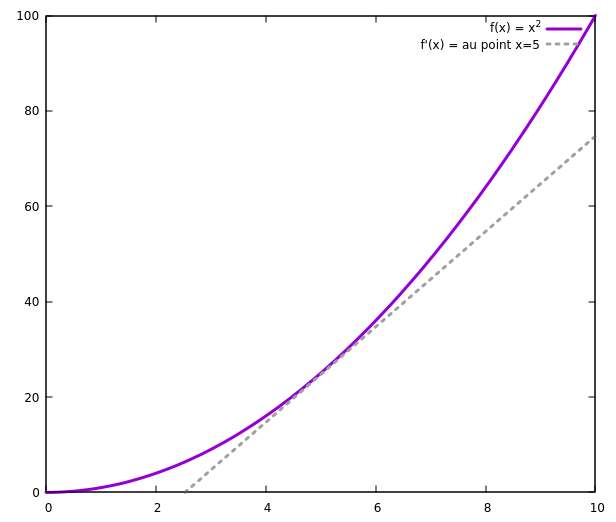

Si on reprend notre formule :

\begin{align*}
f(x) &= 0.1x^4 - 6x^2 + e^x + 120 \\
f'(x) &= 0.4x^3 - 12x + e^x
\end{align*}

Si on évalue $f'(x)$ avec notre $x$ actuel, ça nous donne un
indice sur de quoi a l'air la pente en ce point

- $f'(x) > 0$ : **dérivée positive**
    - Pente qui va vers le haut
    - Si on augmente x, ça fait augmenter $f(x)$
- $f'(x) < 0$ : **dérivée négative**
    - Pente qui va vers le bas
    - Si on augmente x, ça va faire diminuer $f(x)$

La dérivée nous donne aussi un bon indice sur si on doit bouger *peu* ou *beaucoup* notre $x$.

Quand on s'approche d'un minimum local, beaucoup de fonctions ont
*tendance* à ressembler à ça :

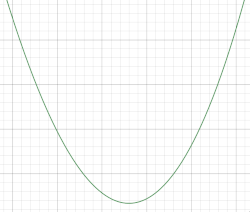

*(C'est loin d'être toujours vrai, mais quand on choisit bien notre fonction, ça peut nous donner de quoi du genre)*

Selon la valeur de la dérivée :

- **Grosse valeur**
    - On est relativement loin du minimum
    - On devrait changer $x$ de beaucoup
- **Petite valeur**
    - On est déjà proche d'un minimum
    - Si on bouge trop $x$ d'un coup, on risque d'*empirer* le score
      en allant trop loin

`=>` On avance *$\approx$ proportionnellement* à la magnitude de la
dérivée, à un certain **taux** choisi arbitrairement

On peut poser par exemple : **1% de la dérivée** à chaque étape

&nbsp;

On modifie graduellement $x$ jusqu'à atteindre une condition d'arrêt. Par exemple : quand $f(x)$ ne bouge presque pas d'un tour à l'autre, on peut s'arrêter.

On va se définir un **seuil de tolérance** arbitraire, par exemple : si $f(x)$ bouge de moins de 0.001 entre deux tours, on considère que l'algorithme a convergé vers la solution. On arrête l'algorithme.

### Algo général pour la descente de gradient à une variable

1. $x$ = valeur de départ (choisie arbitrairement)

2. Regarder $f(x)$ au tour actuel

3. Calculer la valeur de la dérivée au point $x$

4. Modifier $x$ d'un petit pourcentage de la dérivée, par exemple $-0.01 * f'(x)$

5. Tant que $f(x)$ continue de bouger plus vite qu'un certain seuil de tolérance, par exemple :
    
    > *différence absolue entre $f(x_\text{avant})$ et $f(x_\text{apres}) > 0.001$
    
    alors on recommence, on continue de modifier $x$

6. Quand on a atteint un stade où $f(x)$ ne bouge plus beaucoup, on retourne le $x$ final trouvé

# Exercices : descente de gradient simple

**Exercice 1**

Soit la fonction qu'on vient de voir :

\begin{align*}
f(x) &= 0.1x^4 - 6x^2 + e^x + 120 \\
f'(x) &= 0.4x^3 - 12x + e^x
\end{align*}

- Codez la dérivée $f'$
- Codez l'algorithme de la descente de gradient pour trouver la valeur de $x$ qui minimise $f(x)$

In [ ]:
#@title Exercice 1
def f(x):
  return 0.1 * x**4 - 6 * x**2 + np.exp(x) + 120

def f_derivee(x):
  return 0 # TODO: Compléter ça

def optimiser_f(x_depart, taux = 0.01, tolerance = 0.001):
  x = x_depart
  # TODO: La fonction devrait retourner le x qui minimise f(x)

  # Utilisez les variables "taux" et "tolerance" dans votre fonction
  # "taux" = le pourcentage de la dérivée qu'on soustrait à x à chaque tour
  # "tolerance" = la variation maximale avant de déclarer qu'on a une réponse assez bonne
  # Si on change "taux" pour quelque chose de plus petit, x va bouger moins vite, ça va prendre plus de tours
  # Si on change "tolerance" pour quelque chose de plus petit, on devrait avoir une réponse plus précise

  # À chaque tour de boucle, affichez le numéro d'itération + votre estimation actuelle pour le x cherché:
  #     Tour 0: x = 5
  #     Tour 1: x = 3.615868408974234
  #     Tour 2: x = 3.4888336440631913
  #     ....

  return x

#################

def f_derivee(x):
  return 0.4*x**3 - 12*x + np.exp(x)

def optimiser_f(x_depart, taux = 0.01, tolerance = 0.01):
  x = x_depart

  tour = 0
  continuer = True

  while continuer:
    print("Tour", tour, ": x =", x)

    x_avant = x
    x += -taux * f_derivee(x)

    variation = f(x) - f(x_avant)
    if abs(variation) < tolerance:
      continuer = False

    tour += 1

  return x

print(optimiser_f(5))

Tour 0 : x = 5
Tour 1 : x = 3.615868408974234
Tour 2 : x = 3.4888336440631913
Tour 3 : x = 3.4101526052316187
Tour 4 : x = 3.3580437063352924
Tour 5 : x = 3.3222123438834332
Tour 6 : x = 3.296991408968478
Tour 7 : x = 3.278963275765003
Tour 8 : x = 3.2659401081943593
3.2564627398648596


**Exercice 2.1**

Essayez d'appeler la fonction en changeant la tolérance et le taux, testez :

- `optimiser_f(5, tolerance=0.000001)`, ie, on doit trouver la bonne réponse à 6 décimales près

Notez votre observation dans la cellule suivante

In [ ]:
#@title Exercice 2.1
print(optimiser_f(5, tolerance=0.000001))

Tour 0 : x = 5
Tour 1 : x = 3.615868408974234
Tour 2 : x = 3.4888336440631913
Tour 3 : x = 3.4101526052316187
Tour 4 : x = 3.3580437063352924
Tour 5 : x = 3.3222123438834332
Tour 6 : x = 3.296991408968478
Tour 7 : x = 3.278963275765003
Tour 8 : x = 3.2659401081943593
Tour 9 : x = 3.2564627398648596
Tour 10 : x = 3.24952942707889
Tour 11 : x = 3.244438029443949
Tour 12 : x = 3.240688937087095
Tour 13 : x = 3.237922719488702
Tour 14 : x = 3.2358786986424026
Tour 15 : x = 3.23436669031156
Tour 16 : x = 3.2332473311067447
Tour 17 : x = 3.2324181667956347
Tour 18 : x = 3.2318036965013888
Tour 19 : x = 3.2313481830770794
Tour 20 : x = 3.2310104254643908
Tour 21 : x = 3.230759938037673
Tour 22 : x = 3.2305741474726895
Tour 23 : x = 3.230436330217778
3.2303340916302816


**RÉPONSE**

Le nombre de tours augmente, la réponse est meilleure

**Exercice 2.2**

Essayez d'appeler la fonction en changeant la tolérance et le taux, testez :

- `optimiser_f(5, taux=0.00001)`, ie, on change la valeur de $x$ de 0.001% de la dérivée à chaque tour

Notez votre observation dans la cellule suivante

In [ ]:
#@title Exercice 2.2
print(optimiser_f(5, taux=0.00001))

Tour 0 : x = 5
Tour 1 : x = 4.998615868408974
Tour 2 : x = 4.997234038659108
Tour 3 : x = 4.995854503860806
Tour 4 : x = 4.994477257155143
Tour 5 : x = 4.9931022917136785
Tour 6 : x = 4.991729600738277
Tour 7 : x = 4.990359177460931
Tour 8 : x = 4.988991015143581
Tour 9 : x = 4.98762510707794
Tour 10 : x = 4.986261446585318
Tour 11 : x = 4.984900027016448
Tour 12 : x = 4.9835408417513145
Tour 13 : x = 4.98218388419898
Tour 14 : x = 4.980829147797417
Tour 15 : x = 4.979476626013338
Tour 16 : x = 4.978126312342029
Tour 17 : x = 4.976778200307182
Tour 18 : x = 4.975432283460729
Tour 19 : x = 4.97408855538268
Tour 20 : x = 4.972747009680961
Tour 21 : x = 4.971407639991249
Tour 22 : x = 4.970070439976812
Tour 23 : x = 4.968735403328355
Tour 24 : x = 4.967402523763855
Tour 25 : x = 4.966071795028407
Tour 26 : x = 4.964743210894069
Tour 27 : x = 4.963416765159706
Tour 28 : x = 4.962092451650837
Tour 29 : x = 4.960770264219481
Tour 30 : x = 4.959450196744008
Tour 31 : x = 4.958132243128987
Tou

**RÉPONSE**

Ça prend presque 1600 tours plutôt que seulement 10 ou 20, et on termine loin de la bonne réponse...

Il faut ajuster le taux et la tolérence ensemble pour éviter d'avoir du n'importe quoi

**Exercice 2.3**

Essayez d'appeler la fonction en changeant la tolérance et le taux, testez :

- `optimiser_f(5, taux=0.00001, tolerance=0.0000001)`

Notez votre observation dans la cellule suivante

In [ ]:
#@title Exercice 2.3
print(optimiser_f(5, taux=0.00001, tolerance=0.0000001))

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Tour 15391 : x = 3.2441727422715205
Tour 15392 : x = 3.2441690628820745
Tour 15393 : x = 3.2441653844592047
Tour 15394 : x = 3.2441617070026525
Tour 15395 : x = 3.2441580305121596
Tour 15396 : x = 3.244154354987468
Tour 15397 : x = 3.244150680428319
Tour 15398 : x = 3.2441470068344547
Tour 15399 : x = 3.244143334205617
Tour 15400 : x = 3.2441396625415484
Tour 15401 : x = 3.2441359918419903
Tour 15402 : x = 3.244132322106685
Tour 15403 : x = 3.2441286533353746
Tour 15404 : x = 3.2441249855278014
Tour 15405 : x = 3.244121318683708
Tour 15406 : x = 3.244117652802837
Tour 15407 : x = 3.24411398788493
Tour 15408 : x = 3.24411032392973
Tour 15409 : x = 3.24410666093698
Tour 15410 : x = 3.2441029989064223
Tour 15411 : x = 3.2440993378378
Tour 15412 : x = 3.244095677730855
Tour 15413 : x = 3.2440920185853312
Tour 15414 : x = 3.2440883604009714
Tour 15415 : x = 3.2440847031775184
Tour 15416 : x = 3.2440810469147157
To

**RÉPONSE**

On trouve une meilleure réponse, mais en 20 000 tours...

**Exercice 2.4**

Qu'est-ce qui se passe si le taux choisi est plus grand?

Testez avec `taux=0.1` (ie, on modifie $x$ de 10% de la dérivée à chaque tour) et dites ce qui se passe

In [ ]:
#@title Exercice 2.4
# Solution:
# print(optimiser_f(5, taux=0.1))
# Laissé en commentaire, car exécuter ça va causer une boucle infinie!

**RÉPONSE**

$x$ devient `nan` ("Not a number", la valeur est utilisée dans Pandas pour indiquer une valeur manquante, mais ici ça représente une erreur dans le calcul), et le code boucle à l'infini.

## Conclusions qu'on peut tirer de ces tests

Une descente de gradient, c'est délicat... On doit bien choisir la tolérence et le taux.

Problèmes possibles si les valeurs ne sont pas correctes :

- Si la tolérance est incorrecte, l'algo peut s'arrêter trop tôt, avant d'avoir convergé vers une valeur précise
- Si le taux est trop faible, le nombre de tours requis pour arriver à la bonne réponse peut être extrêmement élevé
- Si le taux est trop élevé, on peut très bien *s'éloigner* de la solution à chaque tour de boucle, et donc ne jamais trouver notre minimum

&nbsp;

Pour mitiger le dernier problème, on va souvent avoir recours à un **nombre maximum d'itérations autorisé**, question d'éviter une boucle infinie.

Par exemple : rendu à 1000 itérations, on arrête, peu importe si l'algorithme a convergé ou pas.

# Apprendre une régression linéaire via une descente de gradient

La descente de gradient toute seule n'est **pas** un "modèle" d'apprentissage machine. C'est cependant un algorithme qui peut servir à faire l'entraînement de plusieurs modèles.

&nbsp;

Jusqu'ici, on a utilisé la dérivée d'une fonction arbitraire $f(x)$ pour trouver le $x$ qui minimise $f$.

Dans le contexte de l'apprentissage machine, on va vouloir **trouver les paramètres d'une fonction**, de façon à **minimiser l'erreur commise**.

On doit donc définir une fonction $f_\text{erreur}() = ...$ qui calcule l'*erreur*.

On appelle cette fonction la **fonction de perte** (en anglais, ***loss fonction***).

&nbsp;

On va coder une descente de gradient pour apprendre une régression linéaire simple, à une seule variable. On va commencer par présumer que $b = 0$ (ordonnée à l'origine à 0).

Une régression linéaire avec $b = 0$, ça va prédire la valeur de y avec :

$$y_{\text{prediction } i} = m x_i$$

Selon le $m$ qu'on utilise, la prédiction sera plus ou moins bonne. **On veut apprendre le $m$ qui minimise l'erreur**.

Notre fonction de perte est **l'erreur commise sur notre ensemble de points $x_i$ connus, en fonction du $m$ utilisé** :

\begin{align*}
f_\text{erreur}(m) &= \sum_i^N {(y_i - y_{\text{prediction } i})^2} \\
&= \sum_i^N {(y_i - m x_i)^2}
\end{align*}

Pour trouver la meilleure valeur de $m$, on va donc :

- Dériver $f_{erreur}(m)$
- Choisir un premier estimé de $m$
- Améliorer ce $m$ jusqu'à une certaine précision désirée, via la descente de gradient

### Un peu de terminologie par rapport à la descente de gradient en apprentissage machine

Petit rappel du vocabulaire qu'on a vu jusqu'ici :

- **Fonction de perte**, ou fonction de coût, ou fonction objectif : la fonction à minimiser. Dans un algo d'apprentissage supervisé, ça va calculer à quel point nos paramètres appris à date commettent une grosse erreur sur nos données d'entraînement
- **Paramètre** : une valeur apprise à partir des données d'entraînement. C'est ce que la descente de gradient trouve : c'est une variable dont on cherche la valeur qui va minimiser la fonction de perte.

&nbsp;

La descente de gradient elle-même définit des termes techniques :

- **Taux d'apprentissage**  : le pourcentage de la dérivée qui est utilisé pour mettre à jour nos paramètres
- Une **époque** : c'est un des "tours" dans notre boucle. Quand on a mis à jour nos paramètres en regardant la dérivée par rapport à l'ensemble de nos données d'entraînement, on a complété une *époque*.

&nbsp;

On a aussi parlé du concept d'**hyperparamètre** : une variable qui n'est *pas* apprise, qui doit être sélectionée avant de commencer l'entraînement.

Pour faire une descente de gradient, on a possiblement besoin de définir le **taux d'apprentissage** et la **tolérance** : ces valeurs ne sont pas apprises par l'algorithme, ce sont des **hyperparamètres** à choisir.

### Question 3

Dérivez la fonction $f_{erreur}(m)$ :

\begin{align*}
f_\text{erreur}(m) &= \sum_i^N {(y_i - m x_i)^2} \\
f'_\text{erreur}(m) &= ~~~ ?
\end{align*}

&nbsp;

**Attention:** votre variable de dérivation est $m$. Les différents $x_i$ sont des **constantes** pendant qu'on dérive.

**RÉPONSE**

On utilise la règle de la dérivée en chaîne ici

\begin{align*}
f'_\text{erreur}(m) &= \sum_i^N { 2 (y_i - m x_i) * -x_i }
\end{align*}

**Question 4**

Inspirez-vous de votre code de l'exercice 1 pour écrire une *descente de gradient* qui trouve le meilleur $m$ pour la fonction d'erreur de la régression linéaire.

Plutôt que de faire des `print()` pour voir l'évolution de votre algo, construisez une **liste python contenant toutes les valeurs successives de $m$**.

On va s'en servir pour faire un beau graphique avec plotly.

In [ ]:
#@title Génération de points pour l'exercice 4
np.random.seed(1337)
N = 1000
x = np.random.random(N) * 5
m = 539.71719 # Solution : le m cherché par la descente de gradient
b = 0

bruit = np.random.normal(0, 10, size=N)
bruit = np.sign(bruit) * bruit**2
y = m * x + b + bruit

df = pd.DataFrame({
  "x": x,
  "y": y,
})
px.scatter(df, x="x", y="y")

In [ ]:
#@title Exercice 4
def f_erreur(m, x, y):
  # Somme des erreurs au carré
  return ((y - x * m)**2).sum()


def f_erreur_derivee(m, x, y):
  # TODO: Compléter ça
  # "x" et "y" sont des tableaux numpy 1D, m est un seul float
  return 0


def optimiser_f_erreur(m_depart, taux_apprentissage = 0.01, tolerance = 0.001):
  m = m_depart
  # Repartez du code de l'exercice 1
  # Enlevez les print() de votre code : on va plutôt utiliser un tableau pour
  # noter les différentes valeurs de m au fil du temps
  infos = []
  # À chaque tour de boucle, notez la valeur actuelle de m
  infos.append(m)

  # TODO: Compléter ça

  # La fonction va retourner tout ce tableau, la dernière valeur devrait être le m final appris
  return infos

#################

def f_erreur(m, x, y):
  # Somme des erreurs au carré
  return ((y - x * m)**2).sum()


def f_erreur_derivee(m, x, y):
  return (2 * (y - x * m) * -x).sum()


def optimiser_f_erreur(m_depart, x, y, taux_apprentissage = 0.01, tolerance = 0.001):
  m = m_depart
  # Repartez du code de l'exercice 1
  # Enlevez les print() de votre code : on va plutôt utiliser un tableau pour
  # noter les différentes valeurs de m au fil du temps
  infos = []
  # À chaque tour de boucle, notez la valeur actuelle de m
  infos.append(m)

  tour = 0
  continuer = True

  while continuer:
    m_avant = m
    m += -taux_apprentissage * f_erreur_derivee(m, x, y)
    infos.append(m)

    variation = f_erreur(m, x, y) - f_erreur(m_avant, x, y)

    if abs(variation) < tolerance:

      continuer = False

    tour += 1

  # La fonction va retourner tout ce tableau, la dernière valeur devrait être le m final appris
  return infos

############# tests

# On garde les erreurs
valeurs_de_m = optimiser_f_erreur(1.0, df.x, df.y, taux_apprentissage=0.00001, tolerance=100)
erreurs = [f_erreur(m, df.x, df.y) for m in valeurs_de_m]
infos = pd.DataFrame({'m': valeurs_de_m, 'erreur': erreurs})
infos

,m,erreur
0,1.000000,2.436781e+09
1,90.462690,1.702949e+09
2,165.053225,1.192820e+09
3,227.243932,8.381991e+08
4,279.096141,5.916818e+08
5,322.328509,4.203133e+08
6,358.373988,3.011852e+08
7,388.427316,2.183723e+08
8,413.484619,1.608042e+08
9,434.376431,1.207854e+08


In [ ]:
#@title Démo: Évolution de l'erreur
px.line(infos, x=infos.index, y="erreur", title="Évolution de l'erreur d'entraînement au fil des époques", markers=True)

In [ ]:
#@title Démo: Évolution de la droite apprise après chaque époque
from plotly.graph_objects import Figure

def generer_droite(m, df):
  x = np.linspace(df.x.min(), df.x.max(), 300)

  return pd.DataFrame({
      "x": x,
      "y": x * m,
  })

df_animation = pd.DataFrame([], columns=["x", "y", "source", "epoch"])

for epoch, m in enumerate(infos.m):
  df_droite = generer_droite(m, df)


  df_frame = pd.concat([df.assign(source="points"), df_droite.assign(source="droite")], ignore_index=True).assign(epoch=epoch)

  if df_animation.size == 0:
    df_animation = df_frame
  else:
    df_animation = pd.concat([
        df_animation,
        df_frame
    ], ignore_index=True)

px.scatter(df_animation, x="x", y="y", color="source", animation_frame="epoch")

Si vous avez fait ça correctement, vous devriez voir votre droite converger tranquillement vers la pente qui minimise l'erreur sur les données.


## Descente de gradient à plusieurs variables

Dans l'exercice 4, on codé une descente de gradient qui apprennait **un seul** paramètre : $m$.

Une vraie régression linéaire va typiquement avoir plusieurs coefficients à apprendre $m_1, m_2, ...$ et va aussi avoir une ordonnée à l'origine $b$.

&nbsp;

Petite question, c'est quoi la "dérivée" d'une fonction à plusieurs
variables?

$$f(x_1, x_2) = 2(x_1 - 3)^2 + 7(x_2 + 5)^3$$

`=>` Chaque variable a sa propre dérivée : les dérivées *partielles*

$$\frac{\delta f}{\delta x_1} = \ldots \quad \frac{\delta f}{\delta x_2} = \ldots$$

&nbsp;

On fait comme si on avait une seule variable à la fois, et que toutes
les autres étaient des constantes

$$\frac{\delta f}{\delta x_1} = \text{derivee de } f(x_1, x_2) \text{, en faisant comme si } x_2 \text{ etait une constante}$$

Dans la descente de gradient à plusieurs variables, à chaque étape,
chaque variable se fait soustraire un petit pourcentage de la *dérivée partielle* de la fonction par rapport à elle.

&nbsp;

Le **gradient**, c'est le nom donné au **vecteur de toutes les dérivées partielles**

$$\nabla f(x_1, x_2) = \text{gradient de } f = ( \frac{\delta f}{\delta x_1}, \frac{\delta f}{\delta x_2})$$

**Exercice 5**

On va faire une régression linéaire sur :

$$y = m_1 x + m_2 x^2 + b$$

On a donc **trois paramètres à trouver** : $m_1, m_2, b$

L'idée va être la même qu'à l'exercice précédent : on commence avec une valeur de départ pour chaque paramètre (n'importe quoi au hasard va faire l'affaire), puis à chaque tour de boucle, on modifie chacun de ces trois paramètres en ajoutant un petit pourcentage de la **dérivée partielle** par rapport à ce paramètre.

Donc, à chaque tour :

- $m_1$ += taux * $\frac{\delta f_\text{erreur}}{\delta m_1}$
- $m_2$ += taux * $\frac{\delta f_\text{erreur}}{\delta m_2}$
- $b$ += taux * $\frac{\delta f_\text{erreur}}{\delta b}$

Commencez par utiliser une feuille de papier et un crayon pour trouver les formules des trois dérivées partielles.

La fonction de perte est similaire à tantôt, c'est :

\begin{align*}
f_\text{erreur}(m_1, m_2, b) &= \sum_i^N {(y_i - y_{\text{prédiction } i})^2} \\
&= \sum_i^N {(y_i -  (m_1 x_i + m_2 x_i^2 + b))^2}\end{align*}

**Rappel :** dans chaque formule, portez bien attention à quelle est votre variable de dérivation. Toutes les autres sont considérées comme des constantes.

**RÉPONSE**

\begin{align*}
\frac{\delta f(m_1, m_2, b)}{\delta m_1} &= \sum_i^N {2 (y_i -  (m_1 x_i + m_2 x_i^2 + b)) * - x_i} \\
\frac{\delta f(m_1, m_2, b)}{\delta m_2} &= \sum_i^N {2 (y_i -  (m_1 x_i + m_2 x_i^2 + b)) * - x_i^2} \\
\frac{\delta f(m_1, m_2, b)}{\delta b} &= \sum_i^N {2 (y_i -  (m_1 x_i + m_2 x_i^2 + b)) * -1}
\end{align*}

In [ ]:
#@title Génération de points pour l'exercice 5
np.random.seed(1337)
N = 1000
x = np.random.random(N) * 3
m1 = 1.71719
m2 = -500.71719
b = 1990

bruit = np.random.normal(0, 10, size=N)
bruit = np.sign(bruit) * bruit**2
y = m1 * x + m2 * x**2 + b + bruit

df = pd.DataFrame({"x": x, "y": y})
px.scatter(df, x="x", y="y")

In [ ]:
#@title Exercice 5
def f_erreur(m1, m2, b, x, y):
  # Somme des erreurs au carré
  return ((y - (m1 * x + m2 * x**2 + b))**2).sum()


def f_erreur_derivee_m1(m1, m2, b, x, y):
  return 0 # TODO: Compléter ça

def f_erreur_derivee_m2(m1, m2, b, x, y):
  return 0 # TODO: Compléter ça

def f_erreur_derivee_b(m1, m2, b, x, y):
  return 0 # TODO: Compléter ça


def optimiser_f_erreur(m1_depart, m2_depart, b_depart, taux_apprentissage = 0.01, tolerance = 0.001):
  m1 = m1_depart
  m2 = m2_depart
  b = b_depart
  # Repartez du code de l'exercice 4
  infos = []
  # À chaque tour de boucle, notez les valeurs actuelles de m1, m2 et b
  infos.append([m1, m2, b])

  # TODO: Compléter ça

  # La fonction va retourner tout ce tableau, la dernière valeur devrait être le m final appris
  return infos

#################

def f_erreur(m1, m2, b, x, y):
  # Somme des erreurs au carré
  return ((y - (m1 * x + m2 * x**2 + b))**2).sum()


def f_erreur_derivee_m1(m1, m2, b, x, y):
  return (2 * (y - (m1 * x + m2 * x**2 + b)) * -x).sum()

def f_erreur_derivee_m2(m1, m2, b, x, y):
  return (2 * (y - (m1 * x + m2 * x**2 + b)) * -x**2).sum()

def f_erreur_derivee_b(m1, m2, b, x, y):
  return (2 * (y - (m1 * x + m2 * x**2 + b)) * -1).sum()


def optimiser_f_erreur(m1_depart, m2_depart, b_depart, x, y, taux_apprentissage = 0.01, tolerance = 0.001):
  m1 = m1_depart
  m2 = m2_depart
  b = b_depart
  infos = []
  # À chaque tour de boucle, notez les valeurs actuelles de m1, m2 et b
  infos.append([m1, m2, b])

  tour = 0
  continuer = True

  while continuer:
    m1_avant = m1
    m2_avant = m2
    b_avant = b
    m1 += -taux_apprentissage * f_erreur_derivee_m1(m1, m2, b, x, y)
    m2 += -taux_apprentissage * f_erreur_derivee_m2(m1, m2, b, x, y)
    b += -taux_apprentissage * f_erreur_derivee_b(m1, m2, b, x, y)
    infos.append([m1, m2, b])

    variation = f_erreur(m1, m2, b, x, y) - f_erreur(m1_avant, m2_avant, b_avant, x, y)

    if tour > 3000:
      break

    if abs(variation) < tolerance:

      continuer = False

    tour += 1

  # La fonction va retourner tout ce tableau, la dernière valeur devrait être le m final appris
  return infos

############# tests

# On garde les erreurs
parametres = optimiser_f_erreur(1.0, 1.0, 1.0, df.x, df.y, taux_apprentissage=0.0001, tolerance=0.001)
erreurs = [f_erreur(m1, m2, b, df.x, df.y) for (m1, m2, b) in parametres]
infos = pd.DataFrame({
    'm1': [m1 for (m1, m2, b) in parametres],
    'm2': [m2 for (m1, m2, b) in parametres],
    'b': [b for (m1, m2, b) in parametres],
    'erreur': erreurs})
infos

,m1,m2,b,erreur
0,1.000000,1.000000,1.000000,2.095276e+09
1,-79.931637,-320.779420,315.873191,1.792766e+09
2,226.675739,-205.151266,406.895337,1.141504e+09
3,166.889514,-436.734324,636.182523,9.725687e+08
4,386.135207,-353.208496,704.069530,6.370724e+08
...,...,...,...,...
1024,7.509684,-505.033943,1995.981330,2.948002e+07
1025,7.509359,-505.033846,1995.981535,2.948002e+07
1026,7.509038,-505.033751,1995.981738,2.948002e+07
1027,7.508720,-505.033657,1995.981940,2.948002e+07


In [ ]:
#@title Démo: Évolution de l'erreur
px.line(infos, x=infos.index, y="erreur", title="Évolution de l'erreur d'entraînement au fil des époques", markers=True)

In [ ]:
#@title Démo: Évolution de la régression apprise après chaque époque
from plotly.graph_objects import Figure

def generer_fct(m1, m2, b, df):
  x = np.linspace(df.x.min(), df.x.max(), 300)

  return pd.DataFrame({
      "x": x,
      "y": x * m1 + x**2 * m2 + b,
  })

df_animation = pd.DataFrame([], columns=["x", "y", "source", "epoch"])

for epoch, valeurs in infos.iterrows():
  df_droite = generer_fct(valeurs.m1, valeurs.m2, valeurs.b, df)


  df_frame = pd.concat([df.assign(source="points"), df_droite.assign(source="droite")], ignore_index=True).assign(epoch=epoch)

  if df_animation.size == 0:
    df_animation = df_frame
  else:
    df_animation = pd.concat([
        df_animation,
        df_frame
    ], ignore_index=True)

px.scatter(df_animation, x="x", y="y", color="source", animation_frame="epoch")

### Question 6

Au dernier numéro, j'ai un peu joué avec le taux d'apprentissage et la tolérance, mais ça pourrait probablement être mieux

**Cherchez des valeurs qui font converger la descente de gradient plus rapidement, en moins d'époques**

## Point de départ et point d'arrivée

Pour que la descente de gradient fonctionne, on a besoin de choisir des *valeurs initiales* pour chaque paramètre, qui se feront raffiner en suivant les dérivées partielles de la fonction.

En pratique, on va commencer avec des **valeurs aléatoires** choisies dans un intervalle raisonnable.

&nbsp;

Petite note importante : la descente de gradient trouve **un** minimum (local ou global).

Si notre fonction a plusieurs minimums locaux, il est tout à fait possible que, selon le point de départ choisi, la descente de gradient nous donne un résultat qui n'est pas le minimum global qu'on cherchait.

Si on cherchait à optimiser une fonction comme :

In [ ]:
x_fct_non_convexe = np.linspace(0, 3000, 600)
y_non_convexe = np.sin(0.02 * x_fct_non_convexe) * np.sin(0.001 * x_fct_non_convexe)

px.scatter(pd.DataFrame({"x": x_fct_non_convexe, "y_non_convexe": y_non_convexe}), x="x", y="y_non_convexe", title="Fonction non-convexe")

le point de départ choisi pour estimer $x$ aurait une grande influance sur le minimum trouvé.

# Descente de gradient dans `sklearn`

La descente de gradient est un algorithme passe-partout pour minimiser une fonction, mais il y en a des meilleurs.

Les algos utilisés par `sklearn` dans `LinearRegressor`, `Ridge` et `LinearSVC` sont potentiellement meilleurs que ce qu'on vient de coder.

&nbsp;

*En revanche*, on **peut** forcer `sklearn` à utiliser une descente de gradient pour entraîner un modèle donné, via les modèles généraux `SGDRegressor` et `SGDClassifier`.

`SGDRegressor` et `SGDClassifier` ne sont pas des "modèles" à proprement parler, mais plutôt une *technique* : utiliser la descente de gradient pour optimiser une fonction au choix.

Différentes configurations de ces modèles seront équivalentes à différents modèles d'apprentissage, par exemple :

- `SGDRegressor(loss='squared_error', penalty=none) = LinearRegression()`
- `SGDRegressor(loss='squared_error', penalty='l2', alpha=0.0001) = Ridge(alpha=0.0001)`
- `SGDClassifier(loss='squared_hinge', *, penalty='l2') = LinearSVC()`

&nbsp;

**Avantages d'utiliser ces modèles**

- Pour des problèmes où on a une très, très grosse quantité de données, ces modèles vont **plus vite**
- Plutôt que d'appeler `fit()` pour faire tout l'entraînement d'un seul coup, la méthode **`partial_fit()`** est disponible : ça nous permet d'exécuter **une seule étape de la descente de gradient à la fois**
    - On peut voir le résultat intermédiaire à chaque étape d'entraînement
    - On peut mettre l'entraînement en pause et recommencer plus tard
    - Si on vraiment beaucoup de données (ex.: tellement d'images que ça ne rentre pas dans la RAM de l'ordi) on peut faire un entraînement partiel sur une petite quantité de données à la fois. LinearRegression et SVM ne permettent pas de faire ça aussi facilement.

**Désavantages d'utiliser ces modèles**

- On a subitement des valeurs arbitraires à définir manuellement... Des nouveaux hyperparamètres!
    - Quel *taux d'apprentissage utiliser?*
    - Quel est le nombre d'*époques* maximal avant d'arrêter l'algo?
- **Plus d'hyperparamètres à définir et à tester, ça complexifie le processus et ça demande plus de temps**

&nbsp;

Comme vous devriez l'avoir remarqué à la question 2, mal choisir les hyperparamètres de la descente de gradient va changer drastiquement les résultats

- **Taux d'apprentissage trop élevé** : peut mener à du gros n'importe quoi, on va trop loin et on ne se rapproche plus du minimum
- **Taux d'apprentissage trop bas** : l'entraînement peut être extrêmement long pour rien


## Inspecter l'apprentissage graduel d'une régression sur des images

On va refaire la prédiction de visages du Module 10, mais avec une descente de gradient.

Le code est déjà fourni, vous pouvez l'exécuter pour visualiser comment le modèle apprend les coefficients de la régression Ridge graduellement.

&nbsp;

### Exercice 7

Jouez avec le taux d'apprentissage et le nombre d'époques. Essayez d'avoir un entraînement rapide.

**Pour référence:** l'erreur RMSE de la régression Ridge sur cette tâche qu'on a obtenue au module 10 était d'environ 0.004.

Fichier prêt


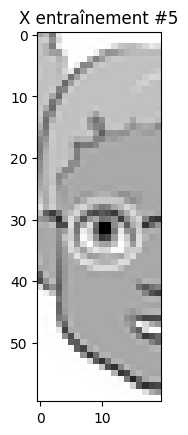

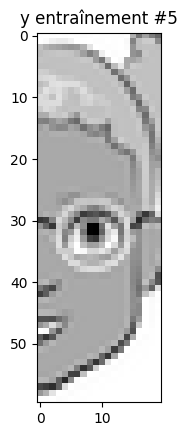

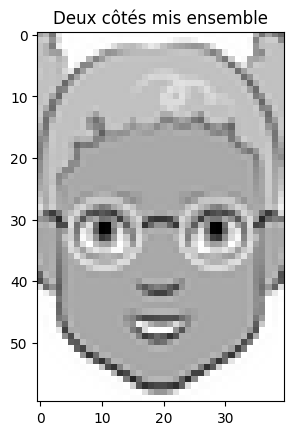

In [ ]:
#@title Code tiré du Module 10 : préparation des données pour la régression sur les visages
!(test -e cartoonset10k.pkl && echo "Fichier prêt") || (wget https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/cartoonset10k.pkl.gz -O cartoonset10k.pkl.gz && gunzip "cartoonset10k.pkl.gz")

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def imshow(matrice, titre="(Image sans titre)", subplot=None):
  axis = plt
  if subplot is not None:
    axis = subplot
  matrice = np.clip(matrice, 0, 1)
  axis.imshow(matrice, cmap="gray", vmin=0, vmax=1)
  if subplot is None:
    axis.title(titre)
    axis.show()

import pickle
with open("cartoonset10k.pkl", "rb") as f:
    faces = [x[20:80, 20:60] for x in pickle.load(f)] # Liste python de matrices numpy

HAUTEUR_IMG, LARGEUR_IMG = faces[0].shape

def afficher_image(i=0):
  imshow(faces[i], f"Image #{i}")

moities_gauches = []
moities_droites = []

for face in faces:
  moities_gauches.append(face[:, :LARGEUR_IMG//2])
  moities_droites.append(face[:, LARGEUR_IMG//2:])

X = np.zeros((10_000, moities_gauches[0].size))
y = np.zeros((10_000, moities_droites[0].size))

i = 0
for image in moities_gauches:
  X[i, :] = image.reshape(LARGEUR_IMG * HAUTEUR_IMG // 2)
  i += 1

i = 0
for image in moities_droites:
  y[i, :] = image.reshape(LARGEUR_IMG * HAUTEUR_IMG // 2)
  i += 1

X_entrainement = X[:500, :]
X_validation = X[500:600, :]
X_test = X[600:700, :]

y_entrainement = y[:500, :]
y_validation = y[500:600, :]
y_test = y[600:700, :]

def afficher_visage(visage1D, titre=None):
  img = visage1D.reshape(HAUTEUR_IMG, LARGEUR_IMG // 2)
  imshow(img, titre)

def afficher_deux_cotes(gauche1D, droite1D, titre=None, plt=None):
  gauche = gauche1D.reshape(HAUTEUR_IMG, LARGEUR_IMG // 2)
  droite = droite1D.reshape(HAUTEUR_IMG, LARGEUR_IMG // 2)
  img = np.concat([gauche, droite], axis=1)
  imshow(img, titre, subplot=plt)

afficher_visage(X_entrainement[5], "X entraînement #5")
afficher_visage(y_entrainement[5], "y entraînement #5")
afficher_deux_cotes(X_entrainement[5], y_entrainement[5], "Deux côtés mis ensemble")

In [ ]:
#@title Entraînement d'une régression Ridge sur les visages via une descente de gradient
from sklearn.linear_model import SGDRegressor
from sklearn.multioutput import MultiOutputRegressor

# Testez différentes valeurs ici: 0.1, 0.01, 0.001
TAUX_APPRENTISSAGE = 0.0001

# Vous pouvez augmenter ce nombre pour laisser l'entraînement aller plus longtemps
NB_EPOQUES = 15

# MultiOutputRegressor --> crée un modèle SGDRegressor() par pixel, basé sur celui défini ici
modele_sgd = MultiOutputRegressor(SGDRegressor(
  # Régression Ridge, alpha = 0.1
  loss='squared_error', penalty='l2', alpha=0.1,
  eta0=TAUX_APPRENTISSAGE,
  learning_rate='constant',
  random_state=1337
))

def epoque():
  modele_sgd.partial_fit(X_entrainement, y_entrainement)

predictions = []
erreur_entrainement = []
erreur_validation = []

def evaluer_erreur():
  y_predictions = modele_sgd.predict(X_entrainement)
  err = root_mean_squared_error(y_entrainement, y_predictions)
  erreur_entrainement.append(err)
  print("Erreur RMSE entrainement:", err)

  y_predictions = modele_sgd.predict(X_validation)
  err = root_mean_squared_error(y_validation, y_predictions)
  erreur_validation.append(err)
  print("Erreur RMSE validation:", err)

  predictions.append(y_predictions)

for i in range(NB_EPOQUES):
  print(f"Époque #{i}")
  epoque()
  evaluer_erreur()

Époque #0
Erreur RMSE entrainement: 0.1615145762120135
Erreur RMSE validation: 0.16458450577292943
Époque #1
Erreur RMSE entrainement: 0.1419098981723478
Erreur RMSE validation: 0.14681650896843915
Époque #2
Erreur RMSE entrainement: 0.13160282840769727
Erreur RMSE validation: 0.13744858726293913
Époque #3
Erreur RMSE entrainement: 0.12517149763438074
Erreur RMSE validation: 0.131610099901507
Époque #4
Erreur RMSE entrainement: 0.12057064529328604
Erreur RMSE validation: 0.12745112069622627
Époque #5
Erreur RMSE entrainement: 0.11698868169687764
Erreur RMSE validation: 0.12422289141170599
Époque #6
Erreur RMSE entrainement: 0.11405267292482965
Erreur RMSE validation: 0.1215776716920865
Époque #7
Erreur RMSE entrainement: 0.11156185896024239
Erreur RMSE validation: 0.11932966481772721
Époque #8
Erreur RMSE entrainement: 0.10939504012969191
Erreur RMSE validation: 0.11736878398731786
Époque #9
Erreur RMSE entrainement: 0.1074736310756682
Erreur RMSE validation: 0.11562509424544863
Époque

In [ ]:
#@title Visualisation de l'entraînement

df_erreurs = pd.DataFrame({
    "erreur_entrainement": erreur_entrainement,
    "erreur_validation": erreur_validation,
    })
display(px.line(df_erreurs, x=df_erreurs.index, y=df_erreurs.columns, title="Erreur d'entrainement et de validation au fil des époques"))


def afficher_prediction(epoque=0, i=33):
  droite = predictions[epoque][i]
  gauche = X_validation[i]
  afficher_deux_cotes(gauche, droite, f"Image #{i}, époque #{epoque}")

from ipywidgets import interact
output = interact(
  afficher_prediction,
  epoque=(0, len(predictions)-1),
  i=(0, len(y_validation)-1)
)

interactive(children=(IntSlider(value=0, description='epoque', max=14), IntSlider(value=33, description='i', m…

# En résumé

- Ce n'est pas toujours possible de résoudre analytiquement un problème mathématique (ie, isoler les variables qu'on cherche)
- En revanche, on peut toujours se tourner vers un **algorithme numérique**
- La **descente de gradient** utilise l'information de la **dérivée** pour trouver les paramètres qui minimisent une fonction
- Le **gradient = le vecteur des dérivées partielles**
- Beaucoup d'algorithmes d'apprentissage machine peuvent être exprimés comme une minimisation d'une certaine erreur sur les données, et donc être résolus avec une descente de gradient
- Quand on entraîne un modèle avec une descente de gradient, on peut facilement **surveiller les résultats intermédiaires**, en particulier **surveiller les erreurs d'entraînement et de validation**
- La descente de gradient a malheureusement plusieurs **hyperparamètres**, ce qui peut complexifier l'entraînement d'un modèle


## Bonus : pourquoi utiliser la descente de gradient plutôt qu'une autre méthode numérique d'optimisation?

La descente de gradient, ça utilise uniquement l'information donnée par la *première dérivée*.

&nbsp;

Pourquoi ne pas utiliser aussi l'information donnée par la **dérivée seconde**? D'autres algorithmes existent : par exemple, la **méthode de Newton** permet de trouver un zéro d'une fonction en utilisant à la fois l'information donnée par la dérivée première et la dérivée seconde. Utiliser cette information permet souvent de **converger plus vite vers la solution**, ie, ça demande moins d'itérations.

&nbsp;

**Question bonus**

Quand on a une fonction de plusieurs variables, le gradient, c'est le *vecteur de toutes les dérivées premières*.

Qu'est-ce que c'est la "dérivée seconde" quand on a une fonction à plusieurs variables?

**Faites une petite recherche pour répondre à cette question**, et formulez une hypothèse sur pourquoi on s'en tient à la descente de gradient en apprentissage machine. *Indice* : réfléchissez au *nombre de paramètres à apprendre* dans la régression sur des images.

**RÉPONSE**

Lorsqu'on a une fonction de N variables :

$$f(x_1, x_2, \ldots, x_N) = ...$$

Il y a $N^2$ dérivées secondes. On doit considérer :

- La dérivée de $f$ par rapport à $x_1$, puis ensuite par rapport à $x_1$
- La dérivée de $f$ par rapport à $x_1$, puis ensuite par rapport à $x_2$
- La dérivée de $f$ par rapport à $x_1$, puis ensuite par rapport à $x_3$
- $\ldots$
- La dérivée de $f$ par rapport à $x_2$, puis ensuite par rapport à $x_1$
- La dérivée de $f$ par rapport à $x_2$, puis ensuite par rapport à $x_2$
- La dérivée de $f$ par rapport à $x_2$, puis ensuite par rapport à $x_3$
- $\ldots$

&nbsp;

La **matrice hessienne** est la matrice NxN de toutes les dérivées secondes d'une fonction à plusieurs variables.

&nbsp;

En apprentissage machine, on va souvent avoir **beaucoup de caractéristiques, donc beaucoup de paramètres à apprendre**. Mettre un gros nombre au carré, c'est rapidement problématique :

- 1000 paramètres `=>` $1000^2$ dérivées secondes = 1 million
- 7680 paramètres `=>` $7680^2$ dérivées secondes = ~59 millions

Pour vous donner une idée, dans la régression sur des images, **chaque pixel utilisait 7680 paramètres**, ce qui aurait fait un total de $7680^2 * 7680$ dérivées secondes = ~452 984 millions, ce qui correspond à 1 812 gigabytes de RAM.

Pour référence, un ordinateur moyen a entre 16 et 32 gigabytes de RAM.